In [5]:
%pip install tensorflow tensorflow-addons albumentations opencv-python-headless scikit-image
%pip install albumentations


import os
from pathlib import Path
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
import numpy as np
import albumentations as A
import cv2
import matplotlib.pyplot as plt


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow-addons (from versions: none)
ERROR: No matching distribution found for tensorflow-addons


  Using cached scipy-1.16.3-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl.metadata (2.4 kB)
  Using cached pydantic-2.12.4-py3-none-any.whl.metadata (89 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pydantic_core-2.41.5-cp313-cp313-win_amd64.whl.metadata (7.4 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
Using cached pydantic-2.12.4-py3-none-any.whl (463 kB)
Using cached pydantic_core-2.41.5-cp313-cp313-win_amd64.whl (2.0 MB)
Using cached annotated_types-0.7.0-py3-none-any.whl (13 kB)
Using cached scipy-1.16.3-cp313-cp313-win_amd64.whl (38.5 MB)
Using cached typing_inspection-0.4.2-py3-none-any.whl (14 kB)
Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl (154 kB)

   -------- -------------------------------  2/10 [stringzilla]
   -------- -------------------------------  2/10 [stringzilla]
   ------------ ---------------------------  3/10 [scipy]
   --------

## Config & parameters

In [6]:
PROJECT_DIR = Path.cwd().parents[0] if (Path.cwd().name == "notebooks") else Path.cwd()
DATA_DIR = PROJECT_DIR / "data" / "classification _dataset"
IMG_SIZE = (224,224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
SEED = 42


## create tf datasets

In [7]:
train_ds = image_dataset_from_directory(
    DATA_DIR / "train",
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)
val_ds = image_dataset_from_directory(
    DATA_DIR / "valid",
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)
test_ds = image_dataset_from_directory(
    DATA_DIR / "test",
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)
class_names = train_ds.class_names
print("Classes:", class_names)


Found 2662 files belonging to 2 classes.
Found 442 files belonging to 2 classes.
Found 215 files belonging to 2 classes.
Classes: ['bird', 'drone']


## Normalization and caching

In [8]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x,y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(lambda x,y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
test_ds = test_ds.map(lambda x,y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)


## Optional: Albumentations augmentation (for saving augmented samples)

f:\Aerial Object Classification & Detection\venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


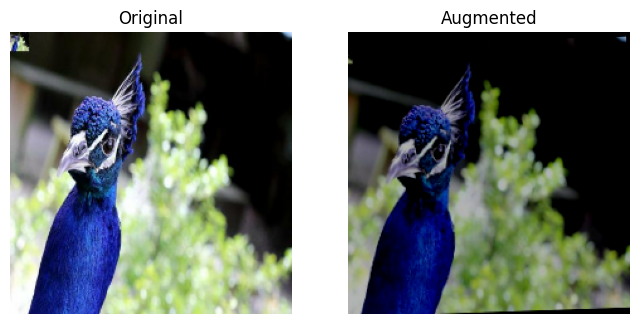

In [10]:
aug = A.Compose([
    A.RandomRotate90(),
    A.HorizontalFlip(),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=20, p=0.7),
    A.RandomBrightnessContrast(p=0.6),
    A.RandomCrop(*IMG_SIZE, p=0.3),
    A.OneOf([A.Blur(), A.GaussNoise()], p=0.3)
])

# Example apply to a single image
for images, labels in train_ds.take(1):
    img = (images[0].numpy()*255).astype("uint8")
    img_aug = aug(image=img)["image"]
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1); plt.imshow(img); plt.title("Original"); plt.axis("off")
    plt.subplot(1,2,2); plt.imshow(img_aug); plt.title("Augmented"); plt.axis("off")
    plt.show()


## Save a small processed TFRecord (optional)

In [11]:
# Optional: create TFRecord for faster training at scale, left as exercise.
print("Preprocessing complete. Datasets ready.")


Preprocessing complete. Datasets ready.
